In [1]:
import mesa
import matplotlib.pyplot as plt

print(mesa.__version__)

3.3.1


## Technology Adoption ABM (Equity + Learning) — Working Notes

### Research question
How much do **learning effects** (cost reductions from cumulative adoption) reduce inequality in adoption between **high-income** and **low-income** households?

### Model setup
- Two household types: `HIGH` income and `LOW` income.
- Income is sampled from gamma distributions (higher mean for `HIGH` group).
- Initial condition: 5% of all agents are randomly set as adopters to seed diffusion.

### Adoption logic (each tick)
A household adopts only if both conditions hold:

1. **Affordability**
   - Adopt if `income > technology_cost`.

2. **Willingness**
   - Bass-style social influence with baseline innovation:
   - Baseline = `0.05`
      - strength of social influence = `0.2`
   - Social term depends on adoption fractions by income group and interaction `Ic`.

For high-income households:
\[
p_{high} = 0.05 + 0.2 \left[(1-Ic) f_{high} + Ic \, f_{low}\right]
\]

For low-income households:
\[
p_{low} = 0.05 + 0.2 \left[(1-Ic) f_{low} + Ic \, f_{high}\right]
\]

where:
- \(f_{high}\): fraction of high-income households that already adopted
- \(f_{low}\): fraction of low-income households that already adopted
- `Ic ∈ [0,1]` controls cross-group influence:
  - `Ic = 0`: no cross-group influence (segregated influence)
  - `Ic = 0.5`: fully mixed influence between groups

### Learning effect (Wright’s law form)
Technology cost decreases with cumulative adopters:
\[
C_t = C_0 \cdot N_t^{-\lambda}
\]
- \(C_0\): initial cost
- \(N_t\): number of adopters at time \(t\)
- \(\lambda\): learning rate

### Key outputs to track
- `fraction_adopted` (overall diffusion)
- `fraction_adopted_high`
- `fraction_adopted_low`
- `adoption_disparity = fraction_adopted_high - fraction_adopted_low`

### Interpretation focus
If learning is strong, early adoption by richer households may lower costs enough to increase later adoption among lower-income households, reducing disparity over time.

In [13]:

from enum import Enum, auto

from mesa import Model, DataCollector
from mesa.agent import AgentSet
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid


class IncomeCategory(Enum):
    HIGH = auto()
    LOW = auto()

#Key word argument for model to understand which technology seeding policy to use for initialization

class SeedPolicy(Enum):
    RANDOM_ALL_5 = auto()         # existing baseline
    RANDOM_LOW_5 = auto()         # new 1
    POOREST_5_BOTH = auto()       # new 2
    POOREST_10_LOW = auto()       # new 3

 #Ic=0 no interaction
 #Ic=0.5 complete interaction.

class Household(CellAgent):
    def __init__(self, model, cell, income, income_type, Ic=0):
        super().__init__(model)
        if not 0 <= Ic <= 1:
            raise ValueError(f"Ic must be in [0, 1], got {Ic}")
        
        self.cell = cell
        self.income = income
        self.income_type = income_type
        self.has_adopted = False
        self.Ic = Ic


    @property
    def willing_to_adopt(self):
        p = self.random.random()
        if self.income_type == IncomeCategory.HIGH:
            willingness_to_adopt = 0.05+0.2*((1-self.Ic) * self.model.fraction_adopted_high + self.Ic * self.model.fraction_adopted_low)
            #(1-Ic weights own group influence, Ic weight other group influence, which is ==0 if Ic 1)
        else:
            willingness_to_adopt = 0.05+0.2*((1-self.Ic) * self.model.fraction_adopted_low + self.Ic * self.model.fraction_adopted_high)
        return willingness_to_adopt > p

    @property
    def able_to_adopt(self):
        return self.model.technology_cost < self.income
    
    def step(self):
        if self.able_to_adopt and self.willing_to_adopt:
            self.has_adopted = True


class TechnologyAdoptionModel(Model):

    def __init__(self, width=50, height=50, rng=None, Ic=0, learning_rate=0.16,                         seed_policy=SeedPolicy.RANDOM_ALL_5):
        super().__init__(rng=rng)

        self.space = OrthogonalMooreGrid((width, height), capacity=1, random=self.random)
        self.technology_cost_0 = 30
        
        self.learning_rate = learning_rate
        self.n_agents = width * height
        self.n_high = 0
        self.n_low = 0

        for cell in self.space:
            if self.random.random() > 0.5:
                income_type = IncomeCategory.LOW
                income = self.random.gammavariate(4, 2)
                self.n_low += 1
            else:
                income_type = IncomeCategory.HIGH
                income = self.random.gammavariate(4, 4)
                self.n_high += 1
            Household(self, cell, income, income_type, Ic=Ic)


        #Eliminated single technology seeding method to replace with key argument
        # n = int(round(self.n_agents * 0.05))
        # for agent in self.agents.shuffle().select(at_most=n):
        #     agent.has_adopted = True

        self._seed_initial_adopters(seed_policy)

        
        self.adopted = self.agents.select(lambda a: a.has_adopted) 
        
        grouped = self.adopted.groupby("income_type").count()
        self.fraction_adopted_high = grouped.get(IncomeCategory.HIGH, 0) / self.n_high
        self.fraction_adopted_low = grouped.get(IncomeCategory.LOW, 0) / self.n_low

        self.data_collector = DataCollector(model_reporters={"fraction_adopted":"fraction_adopted", 
                                                             "technology_cost":"technology_cost",
                                                             "fraction_adopted_high":"fraction_adopted_high",
                                                             "fraction_adopted_low":"fraction_adopted_low",
                                                             "adoption_disparity":"adoption_disparity"})
        self.data_collector.collect(self)

    @property
    def technology_cost(self):
        n = len(self.adopted)
        if n == 0:
            return self.technology_cost_0
        return self.technology_cost_0 * n ** (-self.learning_rate)
    
    @property
    def fraction_adopted(self):
        return len(self.adopted)/self.n_agents

    @property
    def adoption_disparity(self):
        return self.fraction_adopted_high - self.fraction_adopted_low


    # Model initialization paramteres depending on technology seeding key arguments
    def _seed_count(self, pool_size, fraction):
        if pool_size == 0:
            return 0
        return min(pool_size, max(1, int(round(pool_size * fraction))))

    def _seed_initial_adopters(self, seed_policy):
        all_agents = list(self.agents)
        low_agents = [a for a in all_agents if a.income_type == IncomeCategory.LOW]

        if seed_policy == SeedPolicy.RANDOM_ALL_5:
            k = self._seed_count(len(all_agents), 0.05)
            chosen = self.random.sample(all_agents, k) if k > 0 else []

        elif seed_policy == SeedPolicy.RANDOM_LOW_5:
            k = self._seed_count(len(low_agents), 0.05)
            chosen = self.random.sample(low_agents, k) if k > 0 else []

        elif seed_policy == SeedPolicy.POOREST_5_BOTH:
            k = self._seed_count(len(all_agents), 0.05)
            chosen = sorted(all_agents, key=lambda a: a.income)[:k]

        elif seed_policy == SeedPolicy.POOREST_10_LOW:
            k = self._seed_count(len(low_agents), 0.10)
            chosen = sorted(low_agents, key=lambda a: a.income)[:k]

        else:
            raise ValueError(f"Unknown seed_policy: {seed_policy}")

        for agent in chosen:
            agent.has_adopted = True

    def step(self):
        grouped_agents = self.agents.groupby("has_adopted")
        self.adopted = grouped_agents.groups.get(True, AgentSet([], random=self.random))
        
        grouped = self.adopted.groupby("income_type").count()
        self.fraction_adopted_high = grouped.get(IncomeCategory.HIGH, 0) / self.n_high
        self.fraction_adopted_low = grouped.get(IncomeCategory.LOW, 0)  / self.n_low
        
        grouped_agents.groups.get(False, AgentSet([], random=self.random)).shuffle_do("step")
        self.data_collector.collect(self)





In [6]:
model = TechnologyAdoptionModel(rng=31415, Ic=0)

for _ in range(150):
    model.step()

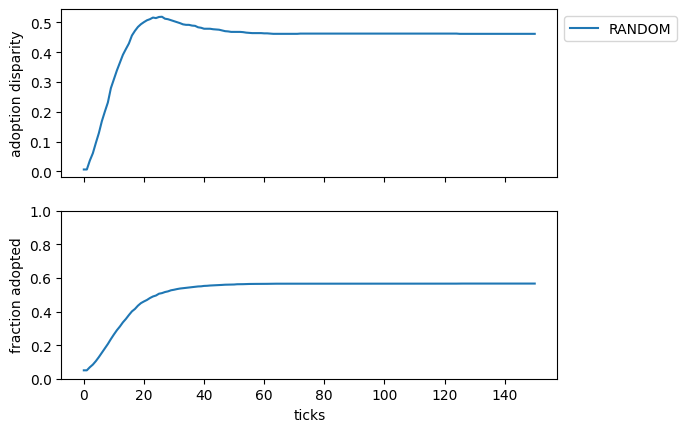

In [7]:
data = model.data_collector.get_model_vars_dataframe()

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)

ax1.plot(data.adoption_disparity, label="RANDOM")
ax2.plot(data.fraction_adopted, label="RANDOM")
ax1.legend(bbox_to_anchor=(1,1))
ax2.set_ylim(ymin=0, ymax=1)

ax1.set_ylabel("adoption disparity")
ax2.set_xlabel("ticks")
ax2.set_ylabel("fraction adopted")
plt.show()

# Question 8: 3 new additinal policies to switch between
Intially the new technology is given to 5% of agents.
Implement 3 additional policies, ensuring it is possible to specify which policy is used vi a keyword argument when instantiating the model. The strategies to be added are:
- Seed the technology randomly only in the low-income population
- Seed the technology to the 5% poorest agents in both income groups
- Seed the technology to the 10% poorest agents in the low-income group

In [15]:
model_random_5 = TechnologyAdoptionModel(rng=31415, Ic=0,
                                seed_policy=SeedPolicy.RANDOM_LOW_5)

In [16]:
model_5_both=model = TechnologyAdoptionModel(rng=31415, Ic=0,
                                seed_policy=SeedPolicy.POOREST_5_BOTH)

In [17]:
model_10_low=model = TechnologyAdoptionModel(rng=31415, Ic=0,
                                seed_policy=SeedPolicy.POOREST_10_LOW)

#

In [ ]:
import numpy as np
import pandas as pd

# Experiment design
ic_values = np.linspace(0.0, 0.5, 4)  # 4 values between 0 and 0.5
lr_values = np.linspace(0.15, 2.0, 4)  # 4 values between 0.15 and 2
n_steps = 150
n_reps = 20  # increase/decrease as needed
base_seed = 31415

records = []

for Ic in ic_values:
    for lr in lr_values:
        for rep in range(n_reps):
            rng_seed = base_seed + rep

            # "Originally provided model" behavior: use defaults besides Ic and learning_rate
            model = TechnologyAdoptionModel(
                rng=rng_seed,
                Ic=float(Ic),
                learning_rate=float(lr)
            )

            for _ in range(n_steps):
                model.step()

            data = model.data_collector.get_model_vars_dataframe()
            final = data.iloc[-1]

            records.append({
                "Ic": float(Ic),
                "learning_rate": float(lr),
                "rep": rep,
                "final_fraction_adopted": float(final["fraction_adopted"]),
                "final_adoption_disparity": float(final["adoption_disparity"]),
                "final_fraction_adopted_high": float(final["fraction_adopted_high"]),
                "final_fraction_adopted_low": float(final["fraction_adopted_low"]),
                "final_technology_cost": float(final["technology_cost"]),
            })

results_df = pd.DataFrame(records)
results_df.head()

In [19]:
summary_df = (
    results_df
    .groupby(["Ic", "learning_rate"], as_index=False)
    .agg(
        mean_fraction_adopted=("final_fraction_adopted", "mean"),
        std_fraction_adopted=("final_fraction_adopted", "std"),
        mean_adoption_disparity=("final_adoption_disparity", "mean"),
        std_adoption_disparity=("final_adoption_disparity", "std"),
    )
)

summary_df

NameError: name 'results_df' is not defined